# HVSR analysis with quiet-window selection

A simple native **hvsrpy** workflow: inputs, waveform-based window selection, one HVSR curve, SESAME checks and exports. No chronological blocks or parameter ranking.

Window selection prioritizes quiet recordings, not the number of passing SESAME criteria. Use the `ciudad-perdida` kernel and run in order. Restart after editing the utilities.

In [2]:
from pathlib import Path
from dataclasses import asdict
import hashlib
import importlib.metadata
import platform
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next((folder for folder in (WORKING_DIR, *WORKING_DIR.parents)
             if (folder / 'utils/hvsr_tools.py').is_file() and (folder / 'data').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Run from the repository root or main/01_processing.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv
from utils import plotting as hp

versions = {name: importlib.metadata.version(name) for name in ('hvsrpy', 'obspy', 'numpy', 'scipy', 'pandas', 'matplotlib')}
versions['python'] = platform.python_version()

## 1. Inputs

Use an N/E/Z dictionary, a component-file list or one multicomponent SEED/miniSEED path. All components need compatible units, response and timing. Gaps are rejected, not interpolated; select a continuous UTC interval with `STARTTIME`/`ENDTIME` if needed. See the README for accelerometer examples. The preserved Minishark ASCII file requires verified channel ordering before conversion.

The three-panel figure is **6.3 inches wide**, with STA/LTA on top and Fourier amplitudes/HVSR below. Edit its layout, colors and drawing code in the dedicated figure cell. Exports are PDF/SVG/600-dpi PNG. Set `SHOW_WINDOW_CURVES=True` for a log-H/V diagnostic showing every accepted curve; the default mean/scatter plot uses linear H/V.

In [3]:
INPUT_FILES = {component: ROOT / f'data/sac/00P2-2_WA.WAU40..HH{component}.D.2020.281.sac' for component in 'NEZ'}
STARTTIME = None
ENDTIME = None
SAVE_OUTPUTS = True
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_PREFIX = '00P2-2'
SHOW_WINDOW_CURVES = False
FIGURE_STYLE = hp.PaperStyle(width_in=6.3, font_size=8.0, tick_size=7.0, legend_size=7.0, dpi=600)
FIGURE_FORMATS = ('pdf', 'svg', 'png')

record = hv.load_record(INPUT_FILES, starttime=STARTTIME, endtime=ENDTIME)
display(pd.Series(record.meta, name='Recording'))

file name(s)                   [/home/orincon/ciudad-perdida-hvsr/data/sac/00...
deployed degrees from north                                                  0.0
current degrees from north                                                   0.0
station                                                                   00P2-2
starttime                                            2020-10-07T08:18:39.000000Z
sampling_rate_hz                                                           100.0
duration_s                                                              28160.99
Name: Recording, dtype: object

## 2. Window selection and processing

The starting profile uses **32-second nonoverlapping windows**, continuously positioned inside quiet intervals rather than constrained to a fixed grid. Every sample must pass the raw N/E/Z absolute-amplitude STA/LTA bounds. A **2-second buffer on both sides** of invalid intervals prevents windows from touching transient boundaries.

A second guard rejects a candidate when any component's **peak/RMS (crest factor) exceeds 6**, evaluated after removing the candidate mean and before taper/filtering. This catches short impulses missed by a 2-second STA. Zero-energy components fail this guard. Threshold 6 is an adjustable screening heuristic, not an instrument clipping threshold or universal optimum; inspect the retained intervals. Set `max_crest_factor=None` to disable it and `transient_padding_s=0` to remove the buffer.

Selection uses only waveforms, not H/V peaks or SESAME passes. No minimum-retention rule or frequency-domain rejection is imposed. `constant` removes each window's mean; `linear` also removes a fitted line. Taper percentage is per side. Keep the peak-search band broad so competing frequencies are not hidden.

In [4]:
params = hv.HVSRParams(
    window_length_s=32.0, overlap_pct=0.0,
    window_selection='continuous',
    anti_trigger=True,
    sta_s=2.0, lta_s=30.0,
    sta_lta_min=0.2, sta_lta_max=2.0,
    sta_lta_components=('N', 'E', 'Z'), sta_lta_amplitude='abs',
    transient_padding_s=2.0, max_crest_factor=6.0,
    clip_threshold_pct=None,
    filter_corners_hz=(None, None), filter_order=5,
    detrend='constant', orient_to_degrees_from_north=None,
    taper_pct_per_side=5.0, fft_zero_padding=False,
    smoothing='konno_and_ohmachi', smoothing_bandwidth=40.0,
    horizontal_combination='squared_average',
    fmin=0.2, fmax=45.0, n_frequencies=800, frequency_spacing='log',
    peak_range_hz=None,
    frequency_domain_rejection=False, fdr_n=2.5,
)
result = hv.run_hvsr(record, params)
display(pd.Series(result.summary(), name='Analysis summary'))
component_spectra = hv.component_fourier_spectra(record, result)

571/880 windows | f0=10.06025 Hz | A0=5.31017


n_grid_windows               880.000000
n_windows_time_selection     571.000000
n_candidates_before_crest    632.000000
n_crest_rejected              61.000000
n_windows                    571.000000
retained_fraction              0.648864
f0_mean_curve_hz              10.060252
A0_mean_curve                  5.310173
f0_windows_hz                  7.657816
f0_windows_low_hz              3.214884
f0_windows_high_hz            18.240830
f0_windows_std_hz              3.257001
A0_windows                     6.131503
fdr_iterations                      NaN
runtime_s                      0.519000
Name: Analysis summary, dtype: float64

### Editable three-panel figure

Edit `FIGURE_CONTROLS` and the plotting code below, then rerun only this cell. The top panel overlays Vertical/North/East **raw STA/LTA**, not waveforms; shading marks accepted windows. The bottom panels show lognormal-mean component Fourier amplitudes and HVSR. No panel letters are added.

Fourier spectra use the same accepted windows, orientation, filter, detrend, taper, FFT and native smoothing as HVSR. Amplitudes are `abs(FFT) * dt` (input units times seconds), not PSD or response-corrected amplitudes. With anti-trigger disabled or a component omitted from selection, its ratio is calculated for display only; it does not change window acceptance. Limits are shown only when anti-trigger is enabled.

/tmp/ipykernel_143079/2725500131.py:70: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 4
  sta_lta_ax.legend(handles, legend_labels, ncols=3, loc='upper right')


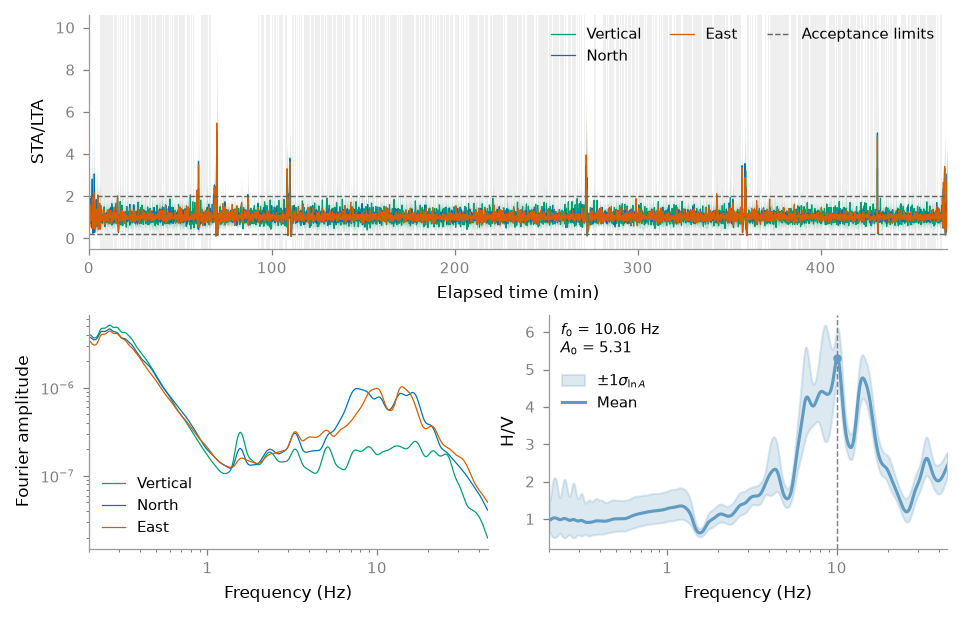

In [5]:
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

FIGURE_CONTROLS = {
    'height_in': 4.0,
    'height_ratios': (1.0, 1.0),
    'component_colors': {'Z': '#009E73', 'N': '#0072B2', 'E': '#D55E00'},
    'component_linestyles': {'Z': '-', 'N': '-', 'E': '-'},
    'line_width': 0.6,
    'accepted_color': '#808080',
    'accepted_alpha': 0.12,
    'sta_lta_max_bins': 4000,
    'sta_lta_ylim': None,
    'fourier_yscale': 'log',
    'hvsr_yscale': None,
    'grid': False,
}

def make_analysis_figure(record, result, component_spectra, controls, style, show_windows=False):
    labels = {'Z': 'Vertical', 'N': 'North', 'E': 'East'}
    attributes = {'Z': 'vt', 'N': 'ns', 'E': 'ew'}
    dt = record.vt.dt_in_seconds
    with hp.paper_context(style):
        figure = plt.figure(figsize=(style.width_in, controls['height_in']), layout='constrained')
        grid = figure.add_gridspec(2, 2, height_ratios=controls['height_ratios'])
        sta_lta_ax = figure.add_subplot(grid[0, :])
        fourier_ax = figure.add_subplot(grid[1, 0])
        hvsr_ax = figure.add_subplot(grid[1, 1], sharex=fourier_ax)

        starts = result.window_starts_s[result.valid_mask] / 60
        length = result.params.window_length_s / 60
        polygons = [[(start, 0), (start + length, 0), (start + length, 1), (start, 1)]
                    for start in starts]
        sta_lta_ax.add_collection(PolyCollection(
            polygons, transform=sta_lta_ax.get_xaxis_transform(),
            facecolors=controls['accepted_color'], alpha=controls['accepted_alpha'],
            edgecolors='none', zorder=0))
        for component, label in labels.items():
            ratio = result.diagnostics['sta_lta'].get(component)
            if ratio is None:
                ratio = hv.sta_lta_ratio(getattr(record, attributes[component]).amplitude, dt,
                                        result.params.sta_s, result.params.lta_s,
                                        result.params.sta_lta_amplitude)
            finite = np.flatnonzero(np.isfinite(ratio))
            if not finite.size:
                warnings.warn(f'{label} STA/LTA has no finite values.', RuntimeWarning)
                continue
            time, lower, upper = hp.waveform_envelope(
                ratio[finite[0]:], dt, max_bins=controls['sta_lta_max_bins'])
            time += finite[0] * dt / 60
            color = controls['component_colors'][component]
            sta_lta_ax.fill_between(time, lower, upper, color=color, alpha=0.25,
                                    linewidth=0, rasterized=True)
            sta_lta_ax.plot(time, (lower + upper) / 2, color=color,
                            linestyle=controls['component_linestyles'][component],
                            lw=controls['line_width'], label=label, rasterized=True)
        if result.params.anti_trigger:
            for index, limit in enumerate((result.params.sta_lta_min, result.params.sta_lta_max)):
                sta_lta_ax.axhline(limit, color='0.4', ls='--', lw=0.7,
                                  label='Acceptance limits' if index == 0 else None)
        sta_lta_ax.set(xlim=(0, (record.vt.n_samples - 1) * dt / 60),
                       xlabel='Elapsed time (min)', ylabel='STA/LTA')
        if controls['sta_lta_ylim'] is not None:
            sta_lta_ax.set_ylim(controls['sta_lta_ylim'])
        handles, legend_labels = sta_lta_ax.get_legend_handles_labels()
        handles.append(Patch(facecolor=controls['accepted_color'], alpha=controls['accepted_alpha']))
        #legend_labels.append(f'Accepted windows (n={result.n_windows})')
        sta_lta_ax.legend(handles, legend_labels, ncols=3, loc='upper right')

        for component, label in labels.items():
            mean = np.exp(np.log(component_spectra[component]).mean(axis=0))
            fourier_ax.plot(result.frequency, mean, label=label,
                            color=controls['component_colors'][component],
                            linestyle=controls['component_linestyles'][component],
                            lw=controls['line_width'])
        fourier_ax.set(xscale='log', yscale=controls['fourier_yscale'],
                       xlim=(result.params.fmin, result.params.fmax), xlabel='Frequency (Hz)',
                       ylabel='Fourier amplitude')
        fourier_ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
        fourier_ax.legend(loc='best')
        hp.plot_hvsr(result, show_windows=show_windows, title='', ax=hvsr_ax,
                     yscale=controls['hvsr_yscale'], style=style)
        for axis in (sta_lta_ax, fourier_ax, hvsr_ax):
            hp.style_axes(axis, grid=controls['grid'], style=style)
        return figure

analysis_figure = make_analysis_figure(record, result, component_spectra, FIGURE_CONTROLS,
                                       FIGURE_STYLE, show_windows=SHOW_WINDOW_CURVES)
plt.show()

## 3. SESAME report

Report all three reliability and six clarity criteria, without changing selection to improve the score. Reliability requires 3/3 and clarity at least 5/6. These checks do not prove a unique physical resonance.

For the supplied station this quiet-window profile retains **571/880 windows** (64.9%), with a mean-curve peak near **10.060 Hz** and amplitude **5.310**. Reliability is **3/3**, clarity **4/6**: **C4 and C5 fail**. This is intentional reporting, not a passing result. Inspect the multiple peaks before interpreting a single resonance.

In [6]:
quality = hv.assess_sesame_quality(result, time_blocks=None)
display(pd.DataFrame(quality['criteria']))
print(f"Reliability: {quality['metrics']['reliability_count']}/3; clarity: {quality['metrics']['clarity_count']}/6")
failed = [row['criterion'] for row in quality['criteria'] if not row['passed']]
if failed:
    warnings.warn('Failed SESAME criteria: ' + ', '.join(failed) + '. Selection has not been relaxed to improve the score.')
if not quality['metrics']['frequency_coverage_complete']:
    warnings.warn('Incomplete f0/4 to 4*f0 coverage: interpret SESAME cautiously.')

,criterion,description,value,comparison,threshold,passed
0,R1,Cycles per window,321.928048,>,10.00,True
1,R2,Total cycles,183820.915665,>,200.00,True
2,R3,"Maximum amplitude scatter in [f0/2, 2*f0]",1.418488,<,2.00,True
3,C1,Minimum amplitude below peak / A0,0.229678,<,0.50,True
4,C2,Minimum amplitude above peak / A0,0.225426,<,0.50,True
5,C3,Peak amplitude,5.310173,>,2.00,True
6,C4,Maximum relative shift of +/-1 sigma peaks,0.150142,<,0.05,False
7,C5,Window-peak standard deviation / f0,0.323749,<,0.05,False
8,C6,Amplitude scatter at f0,1.146006,<,1.58,True


Reliability: 3/3; clarity: 4/6


/tmp/ipykernel_143079/3741451756.py:6: UserWarning: Failed SESAME criteria: C4, C5. Selection has not been relaxed to improve the score.
  warnings.warn('Failed SESAME criteria: ' + ', '.join(failed) + '. Selection has not been relaxed to improve the score.')


## 4. Export

Save mean/scatter curves, selected-window acceptance/peaks, candidate crest-factor decisions, parameters, SESAME results, input hashes, versions and the two figures. There are no block or sweep outputs. Change the prefix for separate runs. Figure exports preserve the 6.3-inch canvas without tight cropping.

In [7]:
if SAVE_OUTPUTS:
    def input_hash(path):
        digest = hashlib.sha256()
        with path.open('rb') as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b''):
                digest.update(chunk)
        return digest.hexdigest()
    paths = [Path(path) for path in record.meta['file name(s)']]
    metadata = {
        'quality': quality, 'versions': versions,
        'figure_style': asdict(FIGURE_STYLE), 'figure_formats': FIGURE_FORMATS,
        'figure_controls': FIGURE_CONTROLS,
        'input_sha256': {str(path.relative_to(ROOT)) if path.is_relative_to(ROOT) else str(path): input_hash(path) for path in paths},
        'requested_interval_utc': {'starttime': STARTTIME, 'endtime': ENDTIME},
    }
    exported = hv.save_outputs(result, OUTPUT_DIR, OUTPUT_PREFIX, extra=metadata)
    figure_exports = {
        'analysis': hp.save_figure(analysis_figure, OUTPUT_DIR / f'{OUTPUT_PREFIX}_analysis', formats=FIGURE_FORMATS, style=FIGURE_STYLE),
    }
    print('Saved to', OUTPUT_DIR)
    display(exported)
else:
    print('Output saving disabled.')

Saved to /home/orincon/ciudad-perdida-hvsr/outputs


{'curve': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_curve.csv'),
 'windows': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_windows.csv'),
 'summary': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_summary.json'),
 'selection': PosixPath('/home/orincon/ciudad-perdida-hvsr/outputs/00P2-2_selection.csv')}